In [231]:
import pandas as pd
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np


1) Realizamos una exploración inicial de los datos, mostrando la dimension, tipo de datos, numeor de valores nulos por columna y los primeros registros

In [232]:
ruta = "."
archivos = os.listdir(ruta)

datasets = {}

for archivo in archivos:
    datasets[archivo] = pd.read_csv(os.path.join(ruta,archivo),sep=None,engine="python")

ParserError: field larger than field limit (131072)

In [ ]:
for nombre, df in datasets.items():
    print("ARCHIVO",nombre)
    print("TAMAÑO",df.shape)
    print("COLUMNAS")
    print(df.columns)
    print("TIPOS DE DATOS:", df.dtypes)
    print("VALORES NULOS:", df.isna().sum())
    print("CABEZERA:", df.head())

ARCHIVO 2001eurocopa_fem_stats.csv
TAMAÑO (19, 47)
COLUMNAS
Index(['id_match', 'home_team', 'away_team', 'home_team_code',
       'away_team_code', 'home_score', 'away_score', 'home_penalty',
       'away_penalty', 'home_score_total', 'away_score_total', 'winner',
       'winner_reason', 'year', 'date', 'date_time', 'utc_offset_hours',
       'group_name', 'matchday_name', 'condition_humidity', 'condition_pitch',
       'condition_temperature', 'condition_weather', 'condition_wind_speed',
       'status', 'type', 'round', 'round_mode', 'match_attendance',
       'stadium_id', 'stadium_country_code', 'stadium_capacity',
       'stadium_latitude', 'stadium_longitude', 'stadium_pitch_length',
       'stadium_pitch_width', 'goals', 'penalties_missed', 'penalties',
       'red_cards', 'game_referees', 'stadium_city', 'stadium_name',
       'stadium_name_media', 'stadium_name_official', 'stadium_name_event',
       'stadium_name_sponsor'],
      dtype='object')
TIPOS DE DATOS: id_match      

2) Creamos 3 variables del tipo DataFrame

In [233]:
partidos = pd.DataFrame()
eventos = pd.DataFrame()
jugadores = pd.DataFrame()

3) Añadimos a cada DataFrame las columnas que nos piden

PARTIDOS:


In [234]:
df_mundial_202 = pd.read_csv("matches_mundial202.csv")
df_mundial_202

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long,asistencia_estadio,temperatura_c
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...,88966.0,31.5
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...,44137.0,23.2
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...,68294.0,28.5
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',...",88966.0,19.7
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...,44198.0,33.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,Korea Republic,Greece,2,NaN,NaN,0,NaN,NaN,Huh Jung-moo,NaN,...,NaN,NaN,NaN,NaN,NaN,['56&rsquor;|2:0|Vasilis Torosidis'],['74&rsquor;|2:0|Kim Nam-il|for Ki Sung-yueng'...,['46&rsquor;|1:0|Christos Patsatzoglou|for Gio...,31513.0,31.3
975,Japan,Costa Rica,0,0.9,NaN,1,0.1,NaN,Hajime Moriyasu,Maya Yoshida,...,NaN,NaN,NaN,NaN,"['44&rsquor;|0:0|Miki Yamane', '84&rsquor;|0:1...","['41&rsquor;|0:0|Anthony Contreras', '62&rsquo...","['46&rsquor;|0:0|Takuma Asano|for Ayase Ueda',...",['65&rsquor;|0:0|Jewison Bennette|for Anthony ...,41479.0,16.2
976,Germany,Sweden,2,1.4,NaN,1,0.9,NaN,Joachim Löw,Manuel Neuer,...,NaN,NaN,Jérôme Boateng · 82,NaN,['71&rsquor;|1:1|Jérôme Boateng'],"['52&rsquor;|1:1|Albin Ekdal', '90+7&rsquor;|2...",['31&rsquor;|0:0|İlkay Gündoğan|for Sebastian ...,['74&rsquor;|1:1|Jimmy Durmaz|for Viktor Claes...,44287.0,30.4
977,Korea Republic,Spain,1,NaN,NaN,3,NaN,NaN,Hoe Taik Lee,Choi Soon-ho,...,NaN,NaN,NaN,NaN,"['28&rsquor;|0:1|Chung Hae-won', '51&rsquor;|1...",NaN,['52&rsquor;|1:1|Noh Soo-jin|for Chung Hae-won...,['76&rsquor;|1:2|Fernando Gómez Colomer|for Em...,32733.0,26.1


In [235]:
df_mundial_2026 = pd.read_csv("matches_mundial2026.csv", sep=";")
df_mundial_2026

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,away_penalty_score,status,result_type,home_xg,away_xg,referee_id,player_of_the_match_id,capacidad_estadio_pct,clima
0,1,11/06/2026,19:00:00,1,1,1,2,2,0,NaN,NaN,Completed,Regular,184,52,42.0,16,63.1,soleado
1,2,11/06/2026,23:00:00,1,7,3,4,2,1,NaN,NaN,Completed,Regular,145,112,5.0,58,91.2,soleado
2,3,06/12/2026,19:00:00,1,6,5,6,1,1,NaN,NaN,Completed,Regular,135,98,15.0,112,NaN,NaN
3,4,12 June 2026,23:00:00,1,3,13,14,4,1,NaN,NaN,Completed,Regular,276,88,11.0,332,88.9,soleado
4,5,"June 13, 2026",15:00:00,1,10,7,8,1,1,NaN,NaN,Completed,Regular,78,154,38.0,157,NaN,soleado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,60,26 de junio de 2026,22:00:00,1,16,22,23,1,1,NaN,NaN,Completed,Regular,112,95,8.0,557,130.5,Soleado
106,11,20260614,21:00:00,1,11,19,20,1,0,NaN,NaN,Completed,Regular,11,95,17.0,479,87.2,Nublado
107,35,20260620,21:00:00,1,14,21,23,5,1,NaN,NaN,Completed,Regular,345,88,29.0,531,74.6,DESPEJADO
108,20,2026-06-16T19:00:00Z,23:59:00,1,15,39,40,3,1,NaN,NaN,Completed,Regular,198,88,10.0,1023,61.0,Lluvia


In [236]:
partidos["fecha_partido"] = pd.concat([df_mundial_202["Date"], df_mundial_2026["date"]], ignore_index=True)
partidos["ronda"] = pd.concat([df_mundial_202["Round"], pd.Series([None]*len(df_mundial_2026))], ignore_index=True)
partidos["estadio"] = pd.concat([df_mundial_202["Venue"], pd.Series([None]*len(df_mundial_2026))], ignore_index=True)
partidos["ciudad_partido"] = partidos["estadio"].str.split(",").str[-1].str.strip()
partidos["pais_partido"] = pd.concat([df_mundial_202["Host"], pd.Series([None]*len(df_mundial_2026))], ignore_index=True)
partidos["seleccion_local"] =  pd.concat([df_mundial_202["home_team"], pd.Series([None]*len(df_mundial_2026))], ignore_index=True)
partidos["seleccion_visitante"] =  pd.concat([df_mundial_202["away_team"], pd.Series([None]*len(df_mundial_2026))], ignore_index=True)
partidos["marcador_local"] =  pd.concat([df_mundial_202["home_score"], df_mundial_2026["home_score"]], ignore_index=True)
partidos["marcador_visitante"] =  pd.concat([df_mundial_202["away_score"], df_mundial_2026["away_score"]], ignore_index=True)
partidos["prorroga"]  = pd.concat([df_mundial_202["Notes"].str.contains("extra time",case=False,na=False).map({True: "SI", False: "NO"}), pd.Series([None]*len(df_mundial_2026))], ignore_index=True)
partidos["penalty_local"] = pd.concat([df_mundial_202["home_penalty"], df_mundial_2026["home_penalty_score"]], ignore_index=True)
partidos["penalty_visitante"] = pd.concat([df_mundial_202["away_penalty"], df_mundial_2026["away_penalty_score"]], ignore_index=True)
partidos["penalty_local"] = partidos["penalty_local"].fillna(0)
partidos["penalty_visitante"] = partidos["penalty_visitante"].fillna(0)
partidos["arbitro"] =  pd.concat([df_mundial_202["Referee"], pd.Series([None]*len(df_mundial_2026))], ignore_index=True)


In [237]:
partidos

,fecha_partido,ronda,estadio,ciudad_partido,pais_partido,seleccion_local,seleccion_visitante,marcador_local,marcador_visitante,prorroga,penalty_local,penalty_visitante,arbitro
0,2022-12-18,Final,"Lusail Iconic Stadium, Lusail",Lusail,Qatar,Argentina,France,3,3,SI,4.0,2.0,Szymon Marciniak
1,2022-12-17,Third-place match,"Khalifa International Stadium, Doha",Doha,Qatar,Croatia,Morocco,2,1,NO,0.0,0.0,Abdulrahman Ibrahim Al Jassim
2,2022-12-14,Semi-finals,"Al Bayt Stadium, Al Khor",Al Khor,Qatar,France,Morocco,2,0,NO,0.0,0.0,César Arturo Ramos
3,2022-12-13,Semi-finals,"Lusail Iconic Stadium, Lusail",Lusail,Qatar,Argentina,Croatia,3,0,NO,0.0,0.0,Daniele Orsato
4,2022-12-10,Quarter-finals,"Al Thumama Stadium, ath-Thumāma",ath-Thumāma,Qatar,Morocco,Portugal,1,0,NO,0.0,0.0,Facundo Tello
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,26 de junio de 2026,None,None,None,None,None,None,1,1,None,0.0,0.0,None
1085,20260614,None,None,None,None,None,None,1,0,None,0.0,0.0,None
1086,20260620,None,None,None,None,None,None,5,1,None,0.0,0.0,None
1087,2026-06-16T19:00:00Z,None,None,None,None,None,None,3,1,None,0.0,0.0,None


JUGADORES:

In [238]:
df_player_stats = pd.read_csv("2026player_stats.csv",sep=";")
df_player_stats


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,shots_on_target,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,Unnamed: 18,average_rating
0,1,JosŽ Raœl Rangel,1,GK,5,5,438,0.0,0.0,0.0,NaN,0.0,0.0,0,0,4.0,7.0,3.0,NaN,7.20
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0.0,1.0,1.0,NaN,1.0,0.0,0,0,NaN,NaN,NaN,NaN,6.68
2,3,CŽsar Jasib Montes,1,DEF,4,4,315,0.0,0.0,1.0,NaN,0.0,1.0,0,0,NaN,NaN,NaN,NaN,7.05
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0.0,0.0,2.0,NaN,1.0,0.0,0,0,NaN,NaN,NaN,NaN,7.08
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0.0,0.0,1.0,NaN,1.0,0.0,0,0,NaN,NaN,NaN,NaN,7.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,1244,Orlando Mosquera,48,GK,3,3,270,0.0,0.0,0.0,NaN,0.0,0.0,0,0,0.0,8.0,4.0,NaN,6.80
1244,1245,Michael Amir Murillo,48,DEF,3,3,270,0.0,0.0,5.0,NaN,0.0,0.0,0,0,NaN,NaN,NaN,NaN,6.93
1245,1246,Azar’as Emmanuel Londono,48,FWD,3,0,53,0.0,0.0,1.0,NaN,0.0,0.0,0,0,NaN,NaN,NaN,NaN,6.57
1246,1247,Roderick Alonso Miller,48,DEF,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN


In [239]:
df_squads =  pd.read_csv("2026squads_and_players.csv",sep=";")
df_squads

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,international_goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8.9336,15,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24.6286,59,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10.9126,69,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10.8759,100,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18.2654,47,3
...,...,...,...,...,...,...,...,...
1243,1244,48,Orlando Mosquera,GK,Al Fayha FC,0.7000,50,0
1244,1245,48,Michael Amir Murillo,DEF,Be ş ikta ş JK,7.8302,94,9
1245,1246,48,Azarías Emmanuel Londono,FWD,CD Universidad Católica,4.4904,13,1
1246,1247,48,Roderick Alonso Miller,DEF,Turan Tovuz,NaN,49,2


In [240]:
df_teams = pd.read_csv("2026nationalteams.csv")

In [241]:
jugadores["nombre_jugador"] = df_player_stats["player_name"]
jugadores["team_id"] = df_player_stats["team_id"]
jugadores = pd.merge(jugadores,df_teams[["team_id","team_name"]].drop_duplicates(subset="team_id"), on="team_id",how="left")
jugadores = jugadores.drop(columns=["team_id"])
jugadores = jugadores.rename(columns={"team_name": "seleccion_nacional"})
jugadores["club_jugador"] = df_squads["club_team"]
#jugadores["partidos_seleccion"] = 
jugadores["posicion"] = df_player_stats["position"]
jugadores["valor_mercado"] = df_squads["market_value_eur"]
jugadores["partidos_jugados"] = df_player_stats["matches_played"]
jugadores["minutos_jugados"] = df_player_stats["minutes_played"]
jugadores["goles"] = df_player_stats["goals"]
jugadores["asistencias"] = df_player_stats["assists"]
jugadores["tiros"] = df_player_stats["shots"]
jugadores["tarjetas_amarillas"] = df_player_stats["yellow_cards"]
jugadores["tarjetas_rojas"] = df_player_stats["red_cards"]
jugadores["paradas"] = df_player_stats["saves"]
jugadores["paradas"] = jugadores["paradas"].fillna(0) ## cambiamos los valores NaN por 0 ya que la mayoria de jugadores no son porteros y pues, no hacen ninguna parada
jugadores["goles_concedidos"] = df_player_stats["goals_conceded"]
jugadores["calificacion_media"] = df_player_stats["average_rating"]

In [242]:
jugadores

,nombre_jugador,seleccion_nacional,club_jugador,posicion,valor_mercado,partidos_jugados,minutos_jugados,goles,asistencias,tiros,tarjetas_amarillas,tarjetas_rojas,paradas,goles_concedidos,calificacion_media
0,JosŽ Raœl Rangel,Mexico,CD Guadalajara,GK,8.9336,5,438,0.0,0.0,0.0,0.0,0.0,7.0,3.0,7.20
1,Jorge Eduardo Sanchez,Mexico,PAOK Saloniki,DEF,24.6286,4,349,0.0,1.0,1.0,1.0,0.0,0.0,NaN,6.68
2,CŽsar Jasib Montes,Mexico,FC Lokomotiv Moscow,DEF,10.9126,4,315,0.0,0.0,1.0,0.0,1.0,0.0,NaN,7.05
3,Edson Omar Alvarez,Mexico,Fenerbahçe SK,DEF,10.8759,4,239,0.0,0.0,2.0,1.0,0.0,0.0,NaN,7.08
4,Johan Felipe Vasquez,Mexico,Genoa CFC,DEF,18.2654,4,360,0.0,0.0,1.0,1.0,0.0,0.0,NaN,7.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,Orlando Mosquera,Panama,Al Fayha FC,GK,0.7000,3,270,0.0,0.0,0.0,0.0,0.0,8.0,4.0,6.80
1244,Michael Amir Murillo,Panama,Be ş ikta ş JK,DEF,7.8302,3,270,0.0,0.0,5.0,0.0,0.0,0.0,NaN,6.93
1245,Azar’as Emmanuel Londono,Panama,CD Universidad Católica,FWD,4.4904,3,53,0.0,0.0,1.0,0.0,0.0,0.0,NaN,6.57
1246,Roderick Alonso Miller,Panama,Turan Tovuz,DEF,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


EVENTOS: 

In [243]:
df_events = pd.read_csv("2026match_register.csv", sep=";")

In [244]:
df_events

,event_id,match_id,minute,event_type,team_id,player_id
0,1,1.0,9.0,Goal,1.0,16.0
1,2,1.0,9.0,Assist,1.0,6.0
2,3,1.0,17.0,Yellow Card,2.0,30.0
3,4,1.0,23.0,Yellow Card,1.0,26.0
4,5,1.0,55.0,Red Card,2.0,39.0
...,...,...,...,...,...,...
859,41,4.0,301.0,Assist,13.0,328.0
860,206,27.0,350.0,Goal,5.0,182.0
861,138,18.0,420.0,Goal,36.0,919.0
862,698,91.0,500.0,Goal,36.0,919.0


In [245]:
eventos["minuto_evento"] = df_events["minute"]
eventos["index_partido"] = df_events["match_id"]
eventos["player_id"] = df_events["player_id"]
eventos = pd.merge(eventos, df_player_stats[["player_id","player_name","team_id"]], on="player_id", how="left")
eventos["tipo_evento"] = df_events["event_type"]
eventos = pd.merge(eventos, df_teams[["team_id","team_name"]].drop_duplicates(subset="team_id"), on="team_id", how="left")
eventos = eventos.rename(columns = {"player_name":"nombre_jugador", "team_name":"seleccion_evento"})
eventos = eventos.drop(columns=["player_id", "team_id"])

In [246]:
eventos

,minuto_evento,index_partido,nombre_jugador,tipo_evento,seleccion_evento
0,9.0,1.0,Juli‡n AndrŽs Quinones,Goal,Mexico
1,9.0,1.0,Erik Antonio Lira,Assist,Mexico
2,17.0,1.0,Teboho Mokoena,Yellow Card,South Africa
3,23.0,1.0,Brian Gutierrez,Yellow Card,Mexico
4,55.0,1.0,Sphephelo S'miso Sithole,Red Card,South Africa
...,...,...,...,...,...
859,301.0,4.0,Alexander Michael Freeman,Assist,USA
860,350.0,27.0,Naceur Mohamed Manai,Goal,Qatar
861,420.0,18.0,Erling Braut Haaland,Goal,Norway
862,500.0,91.0,Erling Braut Haaland,Goal,Norway


4) Una vez, creados los dataframes que nos piden, vamos a limpiarlos teniendo en cuenta los valores duplicados, nulos y/o anómalos que pudieran contener.

Vamos a empezar con el dataframe de partidos:

In [247]:
partidos.head()

,fecha_partido,ronda,estadio,ciudad_partido,pais_partido,seleccion_local,seleccion_visitante,marcador_local,marcador_visitante,prorroga,penalty_local,penalty_visitante,arbitro
0,2022-12-18,Final,"Lusail Iconic Stadium, Lusail",Lusail,Qatar,Argentina,France,3,3,SI,4.0,2.0,Szymon Marciniak
1,2022-12-17,Third-place match,"Khalifa International Stadium, Doha",Doha,Qatar,Croatia,Morocco,2,1,NO,0.0,0.0,Abdulrahman Ibrahim Al Jassim
2,2022-12-14,Semi-finals,"Al Bayt Stadium, Al Khor",Al Khor,Qatar,France,Morocco,2,0,NO,0.0,0.0,César Arturo Ramos
3,2022-12-13,Semi-finals,"Lusail Iconic Stadium, Lusail",Lusail,Qatar,Argentina,Croatia,3,0,NO,0.0,0.0,Daniele Orsato
4,2022-12-10,Quarter-finals,"Al Thumama Stadium, ath-Thumāma",ath-Thumāma,Qatar,Morocco,Portugal,1,0,NO,0.0,0.0,Facundo Tello


In [248]:
print(partidos["prorroga"].value_counts(dropna=False)) ## esta variable vemos que ya esta normalizada, no hace falta cambiar nada.

prorroga
NO      905
None    110
SI       74
Name: count, dtype: int64


In [249]:
print(partidos["ronda"].value_counts(dropna=False))

ronda
Group stage             596
None                    110
Round of 16              97
Quarter-finals           71
First round              49
Semi-finals              40
First group stage        37
Second round             24
Final                    22
Third-place match        20
Second group stage       12
Final stage               6
Group stage play-off      5
Name: count, dtype: int64


Aquí, para los valores que toman la ronda podemos asumir que hay algunos como 'First group stage' y 'First round' que en verdad se refieren a la misma cosa. Vamos a juntar todos los que pensamos que se refieren a la misma cosa:

In [250]:
mapa = {"First group stage": "Group stage","First round": "Group stage","Second round": "Second group stage"}
partidos["ronda"] = partidos["ronda"].replace(mapa)

Vamos a acabar normalizando el texto de todos los valores por si acaso:

In [251]:
columnas_texto = ["estadio", "ciudad_partido", "pais_partido", "seleccion_local", "seleccion_visitante", "arbitro"]
for columna in columnas_texto:
    partidos[columna] = partidos[columna].str.strip()
    

Vamos a ver que columnas contienen valores nulos:

In [252]:
partidos.info()                 # dtypes, non-null counts
partidos.describe(include="all")# min/max/mean, suspicious values
partidos.isna().sum()           # nulls per column
partidos.duplicated().sum()     # duplicate rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha_partido        1089 non-null   object 
 1   ronda                979 non-null    object 
 2   estadio              979 non-null    object 
 3   ciudad_partido       979 non-null    object 
 4   pais_partido         979 non-null    object 
 5   seleccion_local      979 non-null    object 
 6   seleccion_visitante  979 non-null    object 
 7   marcador_local       1089 non-null   int64  
 8   marcador_visitante   1089 non-null   int64  
 9   prorroga             979 non-null    object 
 10  penalty_local        1089 non-null   float64
 11  penalty_visitante    1089 non-null   float64
 12  arbitro              720 non-null    object 
dtypes: float64(2), int64(2), object(9)
memory usage: 110.7+ KB


np.int64(21)

Aquí por ejemplo vemos que la variable con mayor número de valores nulos es la de arbitro. Además tmabién podemos ver que hay muchos registros que les faltan muchos de los valores porque muchass variables tiene exactamente 964 valores non nulos. Por ahora no vamos a eliminarlos pero dependiendo de caules son las variablaes que faltan (si son importantes o no) y el análisis que queramos llevar a cabo, se podrían eliminar. 

Aquí podemos ver los histogramas de las varibales númericas para ver si hay algunos valores sospechosos:


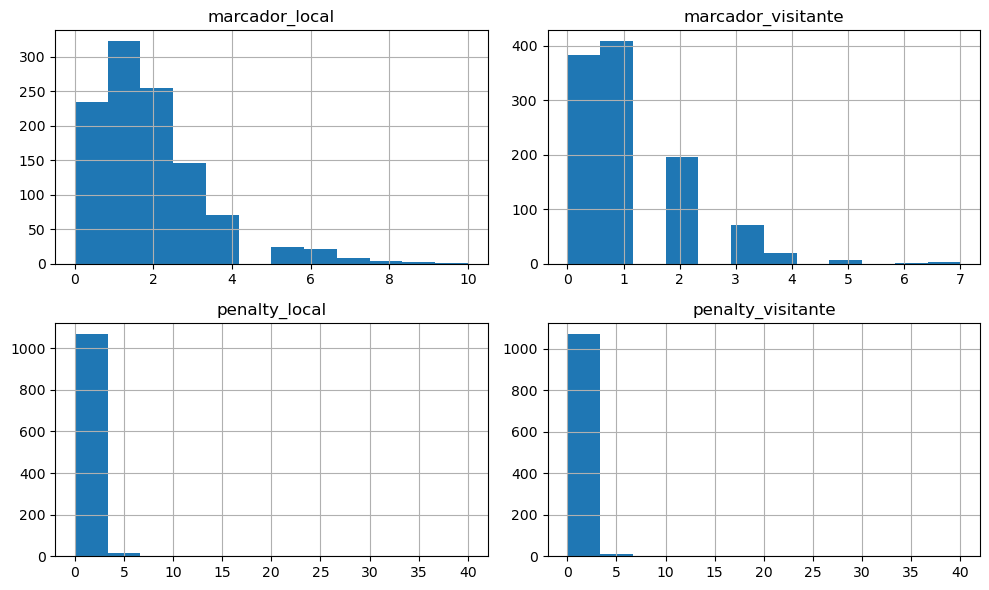

In [253]:
columnas_numericas = ["marcador_local", "marcador_visitante", "penalty_local", "penalty_visitante"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for ax, c in zip(axes, columnas_numericas):
    partidos[c].hist(bins=12, ax=ax)
    ax.set_title(c)

plt.tight_layout()
plt.show()

Podemos ver que la mayoria de valores de penalties, tanto local como visitante es de cero, que tiene sentido. Lo único que es un poco raro el que hay un valor de marcador_local de 10 es poco probable pero seguro siguen siendo posible asique no lo vamos a eliminar de el dataframe.

In [254]:
partidos.describe()

,marcador_local,marcador_visitante,penalty_local,penalty_visitante
count,1089.000000,1089.000000,1089.000000,1089.000000
mean,1.766758,1.059688,0.206612,0.226814
std,1.580196,1.084280,1.839745,2.210224
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000
75%,3.000000,2.000000,0.000000,0.000000
max,10.000000,7.000000,40.000000,40.000000


Aquí borramos todos los duplicados ya que sobran siempre:

In [255]:
partidos = partidos.drop_duplicates()

In [256]:
partidos.nunique()

fecha_partido          474
ronda                    9
estadio                205
ciudad_partido         173
pais_partido            17
seleccion_local         82
seleccion_visitante     86
marcador_local          11
marcador_visitante       8
prorroga                 2
penalty_local            9
penalty_visitante        8
arbitro                322
dtype: int64

Ahora para el dataframe de jugadores:

In [257]:
jugadores.head()

,nombre_jugador,seleccion_nacional,club_jugador,posicion,valor_mercado,partidos_jugados,minutos_jugados,goles,asistencias,tiros,tarjetas_amarillas,tarjetas_rojas,paradas,goles_concedidos,calificacion_media
0,JosŽ Raœl Rangel,Mexico,CD Guadalajara,GK,8.9336,5,438,0.0,0.0,0.0,0.0,0.0,7.0,3.0,7.20
1,Jorge Eduardo Sanchez,Mexico,PAOK Saloniki,DEF,24.6286,4,349,0.0,1.0,1.0,1.0,0.0,0.0,NaN,6.68
2,CŽsar Jasib Montes,Mexico,FC Lokomotiv Moscow,DEF,10.9126,4,315,0.0,0.0,1.0,0.0,1.0,0.0,NaN,7.05
3,Edson Omar Alvarez,Mexico,Fenerbahçe SK,DEF,10.8759,4,239,0.0,0.0,2.0,1.0,0.0,0.0,NaN,7.08
4,Johan Felipe Vasquez,Mexico,Genoa CFC,DEF,18.2654,4,360,0.0,0.0,1.0,1.0,0.0,0.0,NaN,7.08


In [258]:
print(jugadores["nombre_jugador"].value_counts(dropna=False))

nombre_jugador
Ali Ahmed                         2
Jorge Eduardo Sanchez             1
CŽsar Jasib Montes                1
Edson Omar Alvarez                1
Johan Felipe Vasquez              1
                                 ..
Cristian Jesus Martinez           1
Jose Luis Rodriguez               1
Adalberto Eliecer Carrasquilla    1
Tomas Abdiel Rodriguez            1
JosŽ Raœl Rangel                  1
Name: count, Length: 1247, dtype: int64


Aquí ya vemos que el jugador Ali Ahmed tiene dos registros, vamos a ver si es un error:

In [259]:
jugadores[jugadores["nombre_jugador"] == 'Ali Ahmed']

,nombre_jugador,seleccion_nacional,club_jugador,posicion,valor_mercado,partidos_jugados,minutos_jugados,goles,asistencias,tiros,tarjetas_amarillas,tarjetas_rojas,paradas,goles_concedidos,calificacion_media
123,Ali Ahmed,Canada,Norwich City FC,FWD,3.0000,3,158,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN
801,Ali Ahmed,Saudi Arabia,Al Qadsiah FC,GK,5.0329,0,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN


Aquí vemos que son registros completamente diferentes, y haciendo un poco de research en el internet hemos visto que existen 2 Ali Ahmeds uno que juega para canada y otro para Arabia Saudita. Asi que dejamos los dos ahí. 


Normalizamos las demás variables categórica porsi acaso:

In [260]:
columnas_texto = ["seleccion_nacional", "club_jugador", "posicion"]
for columna in columnas_texto:
    jugadores[columna] = jugadores[columna].str.strip()

Como hemos hecho en el dataframe de partidos, vamos a hacer lo mismo aquí(analizamos los nulos):
    

In [261]:
jugadores.info()                 # dtypes, non-null counts
jugadores.describe(include="all")# min/max/mean, suspicious values
jugadores.isna().sum()           # nulls per column
jugadores.duplicated().sum()     # duplicate rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_jugador      1248 non-null   object 
 1   seleccion_nacional  1248 non-null   object 
 2   club_jugador        1248 non-null   object 
 3   posicion            1248 non-null   object 
 4   valor_mercado       1158 non-null   float64
 5   partidos_jugados    1248 non-null   int64  
 6   minutos_jugados     1248 non-null   int64  
 7   goles               1035 non-null   float64
 8   asistencias         1035 non-null   float64
 9   tiros               928 non-null    float64
 10  tarjetas_amarillas  1035 non-null   float64
 11  tarjetas_rojas      1035 non-null   float64
 12  paradas             1248 non-null   float64
 13  goles_concedidos    145 non-null    float64
 14  calificacion_media  928 non-null    float64
dtypes: float64(9), int64(2), object(4)
memory usage: 146.4+

np.int64(0)

Como podemos ver en la tabla de arriba la varible de goles_concedidos tiene un número muy abjo de valores existentes y la mayoria son nulos (88% de valores nulos), para esto hay una explicación bastante lógica ya que los goles concedidos son una estadística que normalmente se utiliza para los porteros. Vamos a comprobarlo usando groupby:

In [262]:
jugadores.groupby("posicion")["goles_concedidos"].count()

posicion
DEF      0
FWD      0
GK     145
MID      0
Name: goles_concedidos, dtype: int64

Ahora vamos a analizar y limpiar las columnas com variables númericas: 

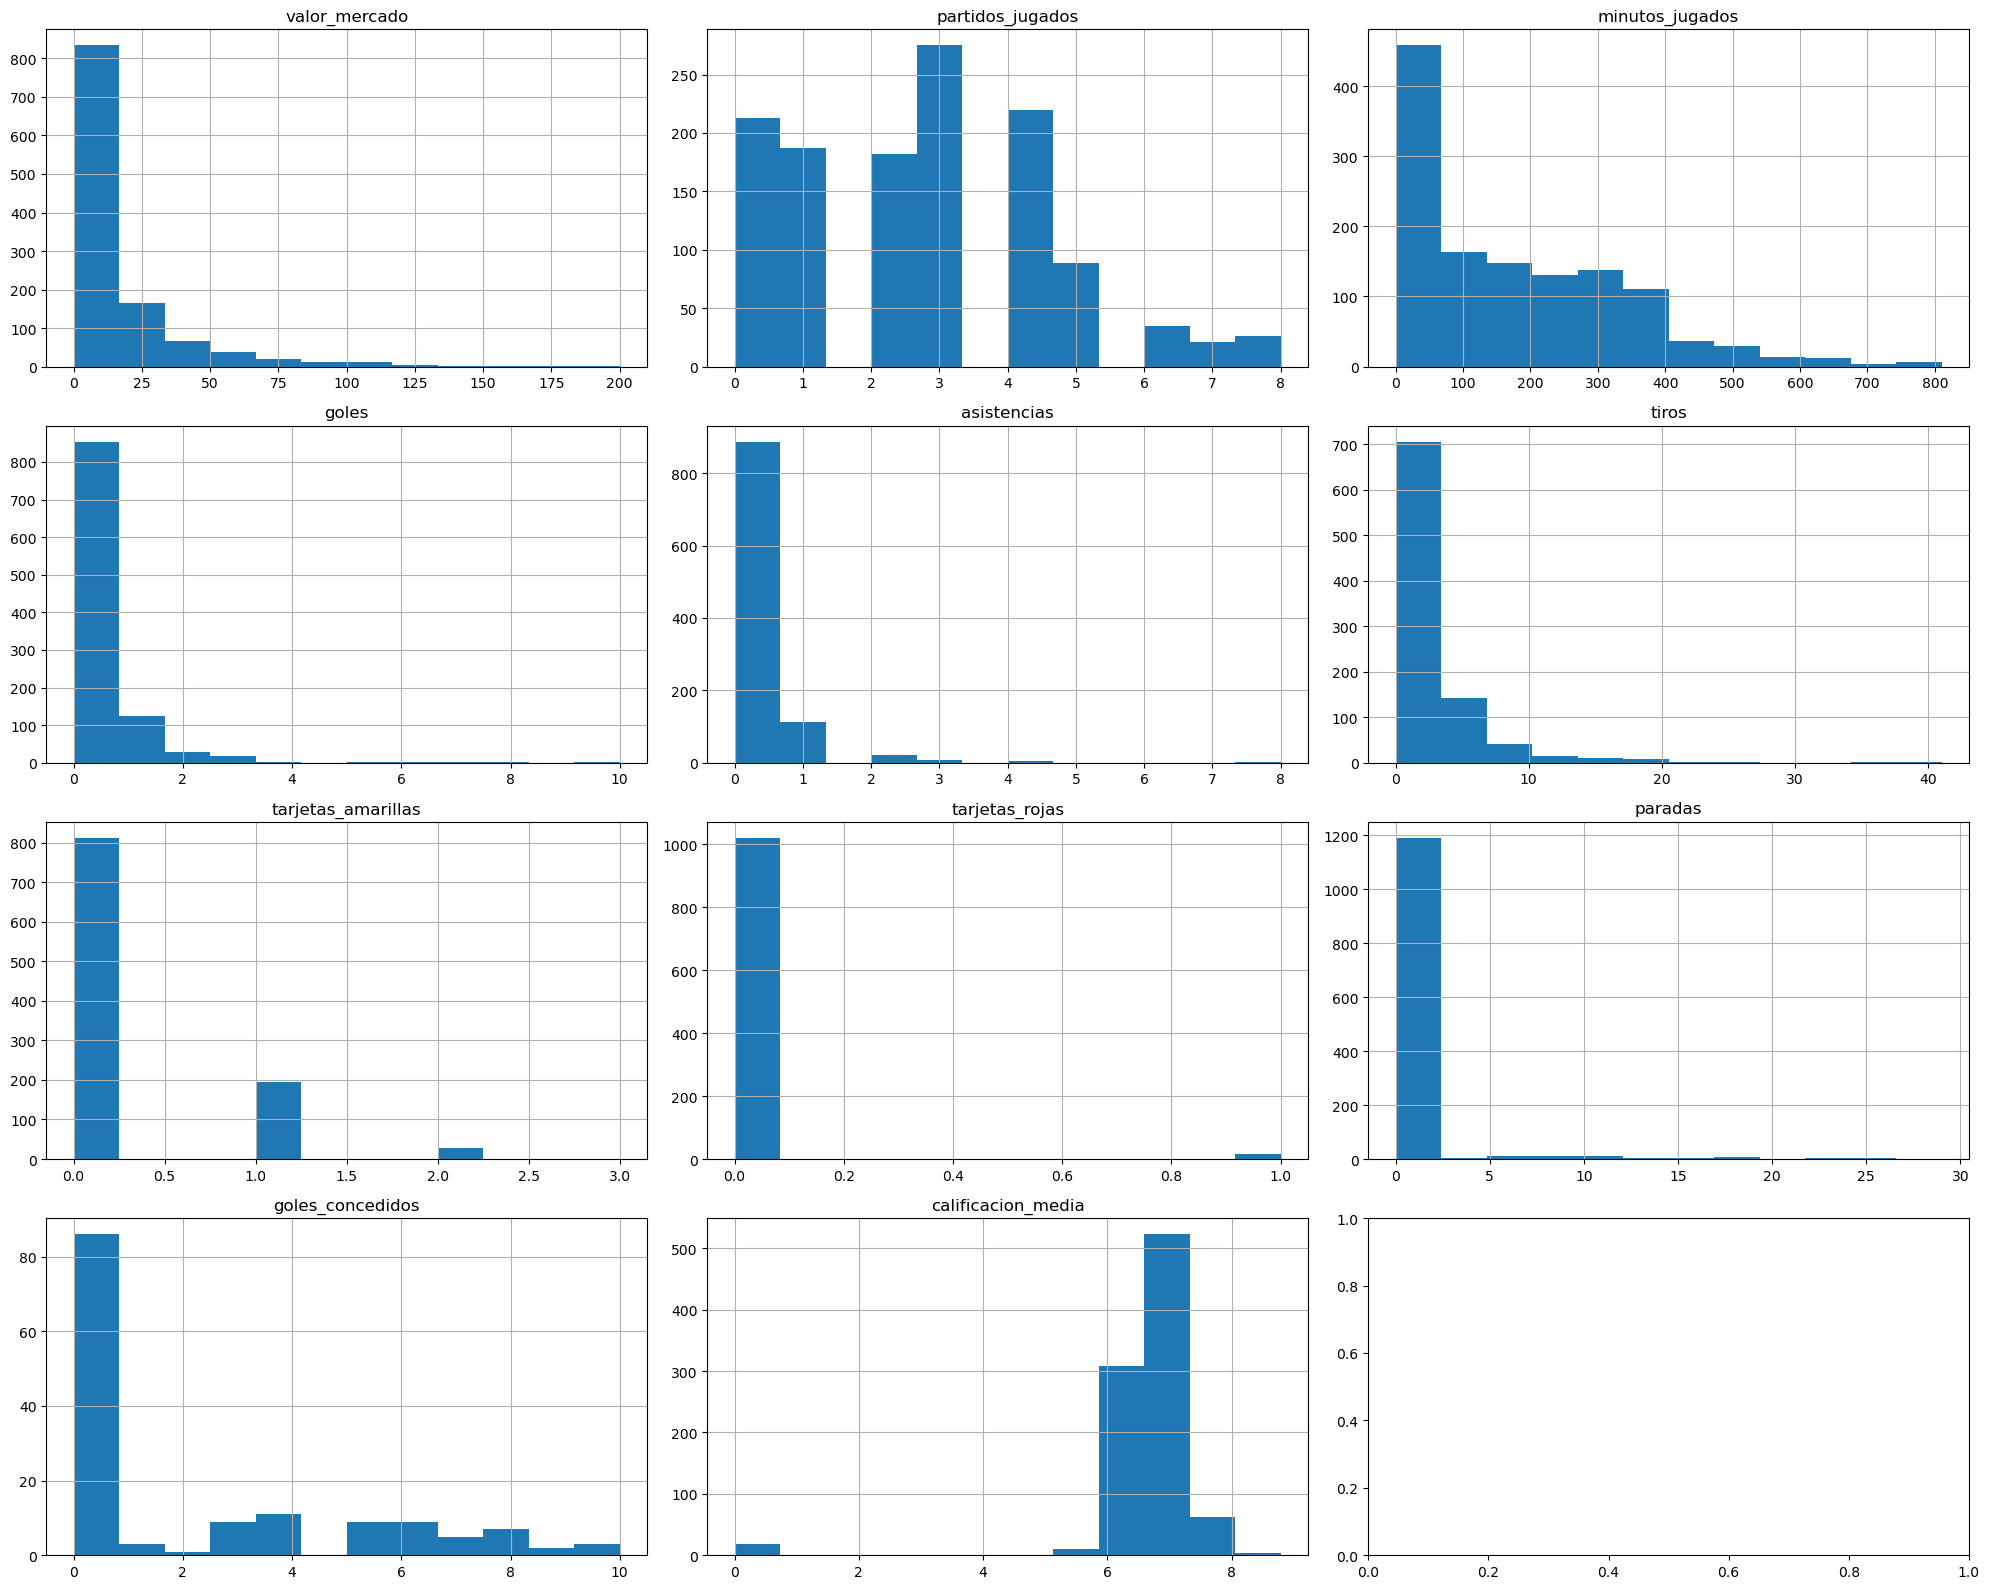

In [263]:
columnas_numericas = ["valor_mercado","partidos_jugados", "minutos_jugados", "goles", "asistencias", "tiros", "tarjetas_amarillas", "tarjetas_rojas", "paradas","goles_concedidos", "calificacion_media"]
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()

for ax, c in zip(axes, columnas_numericas):
    jugadores[c].hist(bins=12, ax=ax)
    ax.set_title(c)

plt.tight_layout()
plt.show()

Al ver estos histogramas podemos ver un par de cosas:
1) paradas tiene muchos ceros que tiene sentido ya que es una estadística qie pertence principalmente a porteros entonces no es algo raro.
2) La mayoria de jugadores tienen una calificacion media entre 6 y 8 pero luego hay unos pocos cerca de cero --> valor centinela?

Vamos a ver primero lo de califiacaion_media

In [264]:
jugadores["calificacion_media"].value_counts(dropna=False).sort_index()

calificacion_media
0.00     18
3.70      1
4.65      1
5.20      1
5.30      2
       ... 
8.10      1
8.24      1
8.45      1
8.79      1
NaN     320
Name: count, Length: 149, dtype: int64

In [265]:
jugadores[jugadores["calificacion_media"] < 5][["nombre_jugador", "partidos_jugados","minutos_jugados", "calificacion_media"]]

,nombre_jugador,partidos_jugados,minutos_jugados,calificacion_media
329,Maximilian Michael Arfsten,1,1,0.00
330,Haji Amir Wright,2,2,0.00
342,Fabi‡n Cornelio Balbuena,1,1,0.00
364,Mathew David Ryan,1,1,0.00
443,Shurandy Ruggerio Sambo,1,1,0.00
458,Brandley Mack-Olien Kuwas,1,1,0.00
596,HŒkan Gustaf Nilsson,1,1,0.00
598,Abdelmouhib Chamakh,1,90,3.70
729,Marc Pubill,1,1,0.00
753,Borja Iglesias,1,1,0.00


Aquí vemos claramente que los valores que tiene una calificaion media de cero es porque han jugado muy poco , como mucho 2 minutos en total. Por esto podemos asumir que el valor 0 se usa para representar la ausencia de una calificaión en lugar de una valoración real de como juago ese jugador. Podemos identificarlos como posibles valores centinela y reemplazar las calificaiones por NaN:


In [266]:
jugadores["calificacion_media"] = jugadores["calificacion_media"].replace(0, np.nan)

In [267]:
jugadores.describe()

,valor_mercado,partidos_jugados,minutos_jugados,goles,asistencias,tiros,tarjetas_amarillas,tarjetas_rojas,paradas,goles_concedidos,calificacion_media
count,1158.000000,1248.000000,1248.000000,1035.000000,1035.000000,928.000000,1035.000000,1035.000000,1248.000000,145.000000,910.000000
mean,15.766116,2.616987,169.757212,0.286957,0.196135,2.517241,0.244444,0.014493,0.556090,2.165517,6.730516
std,23.805162,1.908265,162.725793,0.836645,0.584441,3.883931,0.494804,0.119568,2.837496,2.990758,0.419254
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.700000
25%,2.685300,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.500000
50%,6.537950,3.000000,136.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,6.700000
75%,18.755000,4.000000,270.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,4.000000,6.950000
max,200.000000,8.000000,810.000000,10.000000,8.000000,41.000000,3.000000,1.000000,29.000000,10.000000,8.790000


Eliminamos duplicados si hay:

In [268]:
partidos = partidos.drop_duplicates()

Por ultimo vamos a ver el dataframe de eventos:
Aquí hemos realizado el apartado 5 también.

In [269]:
eventos.head()

,minuto_evento,index_partido,nombre_jugador,tipo_evento,seleccion_evento
0,9.0,1.0,Juli‡n AndrŽs Quinones,Goal,Mexico
1,9.0,1.0,Erik Antonio Lira,Assist,Mexico
2,17.0,1.0,Teboho Mokoena,Yellow Card,South Africa
3,23.0,1.0,Brian Gutierrez,Yellow Card,Mexico
4,55.0,1.0,Sphephelo S'miso Sithole,Red Card,South Africa


In [270]:
eventos.describe()

,minuto_evento,index_partido
count,811.000000,849.000000
mean,60.212084,53.977621
std,51.219155,30.939163
min,-45.000000,1.000000
25%,36.000000,27.000000
50%,58.000000,55.000000
75%,83.000000,80.000000
max,999.000000,104.000000


Con las estadísticas mostradas arriba, ya de primeras podemos ver cosas raras. Por ejemplo el mínimo de el minuto es -45 que debe ser un error ya que no se puede tener un tiempo negativo. Vamos a verlo más de cerca:

In [271]:
eventos[eventos["minuto_evento"] < 0]

,minuto_evento,index_partido,nombre_jugador,tipo_evento,seleccion_evento
108,-5.0,14.0,Timothy Castagne,Yellow Card,Belgium
122,-2.0,16.0,Mohammad Mohebbi,Goal,IR Iran
160,-10.0,21.0,SEMEDONŽlson Nelson,Yellow Card,Portugal
266,-45.0,35.0,Denzel Justus Morris Dumfries,Assist,Netherlands
531,-1.0,70.0,Abdukodir Khusanov,Yellow Card,Uzbekistan


In [272]:
eventos["minuto_evento"].value_counts(dropna=False).sort_index()

minuto_evento
-45.0      1
-10.0      1
-5.0       1
-2.0       1
-1.0       1
          ..
 350.0     1
 420.0     1
 500.0     1
 999.0     1
 NaN      53
Name: count, Length: 119, dtype: int64

Aquí además vemos que hay valores que son altamente grandes, por ejemplo 999. El tiempo normal de un partido podriamos ponerlo como 130 minutos, vamos a ver cuantos valores hay mayor que ese:  

In [273]:
eventos[eventos["minuto_evento"] > 130]

,minuto_evento,index_partido,nombre_jugador,tipo_evento,seleccion_evento
859,301.0,4.0,Alexander Michael Freeman,Assist,USA
860,350.0,27.0,Naceur Mohamed Manai,Goal,Qatar
861,420.0,18.0,Erling Braut Haaland,Goal,Norway
862,500.0,91.0,Erling Braut Haaland,Goal,Norway
863,999.0,2.0,Inbeom Hwang,Assist,South Korea


Como hay valores para la varibale de minuto_evento que incumplen las reglas de dominio, aunque podriían ser error de introduccioón de signo, no tenemos suficiente información para determinar cual sería el valor correcto. Entonces hemos deicidido reemplazarlos por valores NaN:

In [ ]:
eventos.loc[eventos["minuto_evento"] < 0, "minuto_evento"] = np.nan
eventos.loc[eventos["minuto_evento"] > 130, "minuto_evento"] = np.nan


Vamos a investigar los valores ausentes para la variable nombre_jugador:

In [280]:
eventos["nombre_jugador"].value_counts(dropna=False).sort_index()

nombre_jugador
Aaron Buchanan Hickey                         1
Abbosbek Fayzullaev                           1
Abdelaziz Mohame Mostafa                      1
Abdelaziz Moustafa Ramy Rabia                 1
Abdelmegeed Abdelsalam Hossam Abdelmaguid     1
                                             ..
Youri Marion Tielemans                        2
Yousry Fouad Haissem Hassan                   2
Yunus Akgun                                   1
çlvaro Fidalgo                                1
NaN                                          15
Name: count, Length: 451, dtype: int64

In [279]:
eventos[eventos["nombre_jugador"].isna()]

,minuto_evento,index_partido,nombre_jugador,tipo_evento,seleccion_evento
60,NaN,NaN,NaN,NaN,Greenland
587,NaN,NaN,NaN,NaN,Greenland
598,NaN,NaN,NaN,NaN,Greenland
656,NaN,NaN,NaN,NaN,Greenland
819,NaN,NaN,NaN,NaN,Greenland
844,NaN,NaN,NaN,NaN,Greenland
845,NaN,NaN,NaN,NaN,Greenland
846,NaN,NaN,NaN,NaN,Greenland
847,NaN,NaN,NaN,NaN,Greenland
848,NaN,NaN,NaN,NaN,Greenland


podemos ver que estos registros estan casi vacios ya que solo tienen una variable con valor significativo. Vamos a eliminarlas (solo las que tengan los cuatro valores ausentes): 


In [281]:
eventos = eventos.dropna(subset=["minuto_evento","index_partido","nombre_jugador","tipo_evento"],how="all")

In [282]:
eventos["tipo_evento"].value_counts(dropna=False).sort_index()

tipo_evento
Assist                   206
Goal                     317
Penalty Shootout Goal     26
Penalty Shootout Miss     14
Red Card                  15
Review VAR                 6
VAR Review                10
Yellow Card              255
Name: count, dtype: int64

Aquí vemos que hay algunas variable que significan lo mismo, por ejmplo VAR Review y Review VAR son lo mismo. Las unificamos:


In [283]:
eventos["tipo_evento"] = eventos["tipo_evento"].replace("Review VAR", "VAR Review")

C:\Users\isabe\AppData\Local\Temp\ipykernel_39236\3655991109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eventos["tipo_evento"] = eventos["tipo_evento"].replace("Review VAR", "VAR Review")


In [285]:
eventos["seleccion_evento"].value_counts(dropna=False).sort_index()

seleccion_evento
Algeria                   15
Argentina                 42
Australia                 12
Austria                   14
Belgium                   25
Bosnia and Herzegovina    15
Brazil                    28
Cabo Verde                 9
Canada                    18
Colombia                  23
Congo DR                  14
Croatia                   15
Curaçao                    8
Czechia                    5
Côte d'Ivoire             11
Ecuador                   13
Egypt                     31
England                   46
France                    42
Germany                   30
Ghana                      7
Haiti                      8
IR Iran                   10
Iraq                       8
Japan                     18
Jordan                    11
Mexico                    25
Morocco                   24
Netherlands               27
New Zealand               11
Norway                    26
Panama                     5
Paraguay                  25
Portugal                  

No se ve nada raro aquí asi que lo dejamos como estaba. 

6) reconstruir una 'fecha_partido' usando expresiones regulares en el dataframe partidos

In [289]:
partidos

,fecha_partido,ronda,estadio,ciudad_partido,pais_partido,seleccion_local,seleccion_visitante,marcador_local,marcador_visitante,prorroga,penalty_local,penalty_visitante,arbitro
0,2022-12-18,Final,"Lusail Iconic Stadium, Lusail",Lusail,Qatar,Argentina,France,3,3,SI,4.0,2.0,Szymon Marciniak
1,2022-12-17,Third-place match,"Khalifa International Stadium, Doha",Doha,Qatar,Croatia,Morocco,2,1,NO,0.0,0.0,Abdulrahman Ibrahim Al Jassim
2,2022-12-14,Semi-finals,"Al Bayt Stadium, Al Khor",Al Khor,Qatar,France,Morocco,2,0,NO,0.0,0.0,César Arturo Ramos
3,2022-12-13,Semi-finals,"Lusail Iconic Stadium, Lusail",Lusail,Qatar,Argentina,Croatia,3,0,NO,0.0,0.0,Daniele Orsato
4,2022-12-10,Quarter-finals,"Al Thumama Stadium, ath-Thumāma",ath-Thumāma,Qatar,Morocco,Portugal,1,0,NO,0.0,0.0,Facundo Tello
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1078,12 July 2026,None,None,None,None,None,None,3,1,None,0.0,0.0,None
1079,"July 14, 2026",None,None,None,None,None,None,0,2,None,0.0,0.0,None
1080,15-jul-26,None,None,None,None,None,None,1,2,None,0.0,0.0,None
1081,18/07/2026,None,None,None,None,None,None,4,6,None,0.0,0.0,None
